# Notebook : Analyse en Fréquence (Go/NoGo)

Ce notebook guide l'analyse **en fréquence** des données Go/NoGo et l'extraction d'attributs **issus** de ces bandes.

### Remarque importante

La démarche de ce notebook consiste d'abord à explorer et tester le code **individuellement sur un seul sujet**.

Une fois les étapes validées, une **fonction finale** regroupe tous les blocs de code. Cette fonction permet d'appliquer l'ensemble du pipeline de traitement à **tous les sujets** de manière automatisée.

> **Attention :** Si vous avez expérimenté avec différents paramètres (par exemple, d'autres méthodes pour **l'extraction des bandes de fréquence**) et que vous souhaitez utiliser des valeurs autres que celles définies par défaut, **ou si vous avez ajouté d'autres blocs de code ou de nouvelles méthodes**, n'oubliez pas de **mettre à jour la fonction finale** en conséquence avant de l'exécuter sur l'ensemble des données.

Le notebook reprend la structure "Type 1 / Type 2 / Type 3" introduite dans `01_preprocessing_notebook.ipynb` :
- **Type 1 — prêt à exécuter** : cellules complètes, sans modification nécessaire.
- **Type 2 — à personnaliser** : blocs contenant des paramètres à ajuster (balises `A_COMPLETER`).
- **Type 3 — exploration libre** : propositions d'analyses supplémentaires, prêtes à modifier.

## Pour bien démarrer
- Assurez-vous d'avoir exécuté le pipeline de prétraitement pour générer les fichiers `*_clean_epo.fif`. **(Note : L'analyse en fréquence se fait presque toujours sur les époques).**
- Activez l'environnement Python du cours et installez les dépendances (`pip install -r requirements.txt`).

## Objectifs pédagogiques
1. Charger les **époques (epochs)** Go/NoGo déjà prétraitées.
2. Calculer et comparer la **Puissance Spectrale de Densité (PSD)** pour les conditions Go vs NoGo.
3. Appliquer une **analyse Temps-Fréquence (TFR)** pour visualiser l'évolution de la puissance dans le temps (ex: ERD/ERS).
4. **Extraire des attributs (features)** basés sur la puissance moyenne dans des bandes spécifiques (ex: Alpha, Bêta) en vue du Machine Learning.

## 0. Préparation et configuration

Nous commençons par configurer l'environnement d'analyse (imports, chemins, sélection du sujet).


### Bloc Type 1 — Imports et options globales

Initialise les bibliothèques nécessaires, masque certains avertissements MNE et fixe le style de figures Matplotlib.


In [1]:
# -----------------------------------------------------------------------------
# Imports principaux et configuration globale
# Chaque instruction est commentée pour rappeler son rôle.
# -----------------------------------------------------------------------------
import warnings  # contrôle de l'affichage des avertissements Python
from pathlib import Path  # manipulation portable des chemins
import csv  # lecture de fichiers tabulés (.tsv)
import json  # sauvegarde des résultats intermédiaires

import matplotlib.pyplot as plt  # production des figures
import mne  # bibliothèque cœur pour les analyses EEG/MEG
from mne.time_frequency import tfr_morlet  # analyse temps-fréquence
import numpy as np  # opérations numériques vectorisées
import mne_bids  # outils pour gérer la structure BIDS avec MNE
from mne_bids import BIDSPath  # construction de chemins compatibles BIDS

warnings.filterwarnings('ignore', category=RuntimeWarning)  # masque certains avertissements MNE
mne.set_log_level('INFO')  # verbosité modérée pour suivre les étapes clés
plt.rcParams['figure.figsize'] = (10, 5)  # taille par défaut des figures Matplotlib

print('Versions utilisées:')  # journalise les versions pour la reproductibilité
print(' - mne      ', mne.__version__)  # version de MNE
print(' - numpy    ', np.__version__)  # version de NumPy
print(' - mne_bids ', mne_bids.__version__)  # version de mne-bids


Versions utilisées:
 - mne       1.10.1
 - numpy     2.2.6
 - mne_bids  0.17.0


### Bloc Type 1 — Définir le dossier BIDS et les dérivés

Localise le dossier BIDS (données brutes) ainsi que les dérivés produits par le pipeline :
- `derivatives/preproc` pour les fichiers prétraités (sortie du notebook 01),
- `derivatives/gonogo-erp` pour les ERPs de groupe fournis,
- `derivatives/gonogo-analysis` pour les résultats sauvegardés par ce notebook.


In [2]:
# -----------------------------------------------------------------------------
# Localisation des données BIDS et des dérivés nécessaires
# -----------------------------------------------------------------------------
root_bids = Path('tasks/gonogo/bids')  # chemin relatif recommandé

print('Chemins vérifiés:')  # confirmation dans la console
print(' - BIDS root            :', root_bids.resolve())  # chemin absolu utilisé

deriv_preproc = root_bids / 'derivatives' / 'preproc'  # mêmes dérivés que le notebook de prétraitement
deriv_preproc.mkdir(parents=True, exist_ok=True)

deriv_erp = root_bids / 'derivatives' / 'gonogo-erp'  # ERP de groupe fournis

deriv_analysis = root_bids / 'derivatives' / 'gonogo-analysis'  # résultats spécifiques à ce notebook
deriv_analysis.mkdir(parents=True, exist_ok=True)
print(' - Dérivés (preproc)    :', deriv_preproc.resolve())
print(' - Dérivés (analysis)   :', deriv_analysis.resolve())


Chemins vérifiés:
 - BIDS root            : /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/gonogo/bids
 - Dérivés (preproc)    : /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/gonogo/bids/derivatives/preproc
 - Dérivés (analysis)   : /Users/hamzaabdelhedi/Projects/Tutorials/PSY2007A2025/tasks/gonogo/bids/derivatives/gonogo-analysis


### Bloc Type 1 — Lister les participants disponibles

Lit `participants.tsv` (convention BIDS) pour récupérer les identifiants `sub-XX` disponibles. 
En Type 2 ci-dessous, nous choisirons l'un de ces sujets.


In [3]:
# -----------------------------------------------------------------------------
# Lecture de participants.tsv afin d'obtenir la liste des sujets présents
# -----------------------------------------------------------------------------
participants_tsv = root_bids / 'participants.tsv'  # chemin vers le fichier BIDS
subjects = []  # contiendra les identifiants sans le préfixe 'sub-'

with participants_tsv.open('r', encoding='utf-8') as f:  # ouverture du fichier en lecture
    reader = csv.reader(f, delimiter='	')  # lecture tabulée
    header = next(reader, None)  # saute l'entête (participant_id, ...)
    for row in reader:  # boucle sur chaque ligne restante
        if not row:  # ignore les lignes vides
            continue
        participant_id = row[0]  # première colonne = identifiant sujet
        if participant_id.startswith('sub-'):  # vérifie le format BIDS
            subjects.append(participant_id.replace('sub-', ''))  # stocke l'identifiant sans préfixe

print(f"Participants détectés ({len(subjects)}): {subjects}")  # affiche la liste obtenue


Participants détectés (12): ['01', '02', '03', '04', '05', '06', '07', '08', '10', '12', '13', '14']


### Bloc Type 2 — Sélectionner un participant et une session

Modifiez les variables ci-dessous pour cibler un autre enregistrement. 
Les valeurs proposées correspondent à un exemple valide, mais n'hésitez pas à tester différents sujets.


In [4]:
# -----------------------------------------------------------------------------
# Choix du sujet/session/run à analyser (modifiable)
# -----------------------------------------------------------------------------
# On va commenecer par un sujet unique pour simplifier l'exemple. A la fin du notebook,
# on a une fonction qui permet de boucler sur tous les sujets.
subject = '03'  # <--- remplacez par ex. '05' pour explorer un autre participant
session = '001'  # on n'a qu'une session dans ce dataset
run = '01'  # un seul run Go/NoGo disponible

print(f'Sujet en cours: sub-{subject}, session {session}, run {run}')  # trace la sélection


Sujet en cours: sub-03, session 001, run 01


## 1. Charger un enregistrement prétraité

Nous chargeons le fichier `*_clean.fif` issu du pipeline précédent, appliquons un montage standard et vérifions les métadonnées clés.


### Bloc Type 1 — Fonction utilitaire de chargement

`load_processed_raw` centralise la construction du chemin de fichier, le chargement `Raw` MNE et l'application d'un montage 10-20 international.


In [6]:
# -----------------------------------------------------------------------------
# Fonction utilitaire : chargement d'un fichier prétraité pour un sujet donné
# -----------------------------------------------------------------------------
def load_processed_raw(subject: str, session: str = '001', run: str = '01') -> mne.io.BaseRaw:
    # Construit le chemin BIDS du fichier *_processed.fif dans derivatives/preproc
    processed_bids = BIDSPath(
        root=deriv_preproc,
        subject=subject,
        session=session,
        task='gonogo',
        run=run,
        datatype='eeg',
        suffix='eeg',
        processing='clean',
        extension='.fif'
    )
    fname = processed_bids.fpath
    if not fname.exists():  # garde-fou si le fichier manque
        raise FileNotFoundError(f'Fichier introuvable: {fname}')  # message explicite
    raw_obj = mne.io.read_raw_fif(fname, preload=True)  # charge en mémoire pour un accès rapide
    raw_obj.set_montage('standard_1020', match_case=False, on_missing='warn')  # assure la co-registration EEG
    return raw_obj  # renvoie l'objet Raw prêt à l'emploi

raw = load_processed_raw(subject, session=session, run=run)  # chargement effectif
print(raw)  # résumé de l'objet Raw


Opening raw data file tasks/gonogo/bids/derivatives/preproc/sub-03/ses-001/eeg/sub-03_ses-001_task-gonogo_run-01_proc-clean_eeg.fif...
    Range : 0 ... 114599 =      0.000 ...   381.997 secs
Ready.
Reading 0 ... 114599  =      0.000 ...   381.997 secs...
<Raw | sub-03_ses-001_task-gonogo_run-01_proc-clean_eeg.fif, 27 x 114600 (382.0 s), ~23.6 MiB, data loaded>


## 2. Détection des événements et création des epochs

Comme en `04_analysis1_gonogo.ipynb`, ous mappons les annotations BIDS vers des étiquettes lisibles (`go/onset`, `nogo/onset`, ...), puis nous découpons les données en epochs alignés sur ces événements.


### Bloc Type 1 — Extraire les événements Go/NoGo depuis les annotations

La table `annotation_map` relie les identifiants bruts (`Stimulus/S  4`, `Stimulus/S  5`, ...) à des labels plus explicites.


In [7]:
import pandas as pd
# -----------------------------------------------------------------------------
# Étape 1 : Extraction initiale et définition des codes
# -----------------------------------------------------------------------------
events, event_id = mne.events_from_annotations(raw)

# Nouveaux codes pour nos événements
new_event_codes = {
    'stimulus/go/correct': 101,
    'stimulus/go/incorrect': 102, # Erreur d'omission (pas de réponse)
    'stimulus/nogo/correct': 103, # Omission correcte
    'stimulus/nogo/incorrect': 104 # Erreur de commission (réponse erronée)
}

# Dictionnaire pour MNE, qui sera rempli dynamiquement
selected_event_id = {}

# Obtenir les anciens codes sources (en utilisant .get())
go_onset_code = event_id.get(np.str_('go_onset'))
nogo_onset_code = event_id.get(np.str_('nogo_onset'))
go_correct_code = event_id.get(np.str_('go_correct'))
nogo_correct_code = event_id.get(np.str_('nogo_correct'))
incorrect_code = event_id.get(np.str_('incorrect'))

# Codes de stimulus et de réponse
stimulus_codes = [go_onset_code, nogo_onset_code]
response_codes = [go_correct_code, nogo_correct_code, incorrect_code]

# -----------------------------------------------------------------------------
# Étape 2 : Boucle pour renommer les événements
# -----------------------------------------------------------------------------
print("Analyse de la séquence d'événements pour créer des essais stimulus-locked...")

new_events_list = [] # Notre future matrice d'événements
behavioral_data = [] # Pour stocker les TR et la justesse
sfreq = raw.info['sfreq']
trial_count = 0

for i in range(len(events)):
    # On ne s'intéresse qu'au DÉBUT d'un essai (un stimulus onset)
    current_code = events[i, 2]
    if current_code not in stimulus_codes:
        continue
        
    # --- On a trouvé un stimulus ! ---
    trial_count += 1
    t_onset = events[i, 0] # L'échantillon (sample) du stimulus
    stim_type = 'go' if current_code == go_onset_code else 'nogo'
    
    # --- Maintenant, "regardons en avant" pour trouver la réponse ---
    found_response = False
    for j in range(i + 1, len(events)):
        next_code = events[j, 2]
        
        # Cas 1 : On trouve la réponse
        if next_code in response_codes:
            found_response = True
            t_response = events[j, 0]
            rt_sec = (t_response - t_onset) / sfreq
            
            if stim_type == 'go':
                if next_code == go_correct_code:
                    # Essai Go Réussi
                    new_code = new_event_codes['stimulus/go/correct']
                    response = 'correct'
                else:
                    # Essai Go Échoué (ex: 'incorrect')
                    new_code = new_event_codes['stimulus/go/incorrect']
                    response = 'incorrect'
            
            else: # stim_type == 'nogo'
                if next_code == nogo_correct_code:
                    # Essai NoGo Réussi (l'annotation 'nogo_correct' existe)
                    new_code = new_event_codes['stimulus/nogo/correct']
                    response = 'correct'
                    rt_sec = np.nan # Pas de TR pour une non-réponse
                else:
                    # Essai NoGo Échoué (ex: 'incorrect' ou 'go_correct')
                    # C'est une ERREUR DE COMMISSION
                    new_code = new_event_codes['stimulus/nogo/incorrect']
                    response = 'incorrect'
            
            # On a notre réponse, on sort de la boucle "look-ahead"
            break
            
        # Cas 2 : On trouve le PROCHAIN stimulus (essai manqué)
        if next_code in stimulus_codes:
            # On a atteint le stimulus suivant sans trouver de réponse
            found_response = False
            break

    # Cas 3 : On n'a pas trouvé de réponse avant la fin (ou avant le prochain stimulus)
    if not found_response:
        rt_sec = np.nan # Pas de réponse
        
        if stim_type == 'go':
            # Essai Go manqué -> ERREUR D'OMISSION
            new_code = new_event_codes['stimulus/go/incorrect']
            response = 'incorrect'
        else: # stim_type == 'nogo'
            # Essai NoGo manqué (pas de réponse) -> C'EST CORRECT
            new_code = new_event_codes['stimulus/nogo/correct']
            response = 'correct'

    # --- Ajouter l'événement STIMULUS-LOCKED renommé ---
    # On ajoute le [t_onset, 0, new_code]
    new_events_list.append([t_onset, 0, new_code])
    
    # --- Ajouter les données comportementales ---
    behavioral_data.append({
        'trial': trial_count,
        'stimulus': stim_type,
        'response': response,
        'rt_sec': rt_sec
    })

# -----------------------------------------------------------------------------
# Étape 3 : Finalisation et Résumé
# -----------------------------------------------------------------------------

# Convertir la liste en matrice numpy, comme MNE s'y attend
events_modified = np.array(new_events_list)

# Créer le dictionnaire event_id final
selected_event_id = {label: code for label, code in new_event_codes.items() 
                     if code in events_modified[:, 2]} # Ne garde que les événements existants

# Convertir les données comportementales en DataFrame Pandas pour inspection
df_behavior = pd.DataFrame(behavioral_data)

print("\n--- Résumé du Renommage Stimulus-Locked ---")
print(f"Total d'essais (stimulus) trouvés : {trial_count}")
print("Nouveaux événements créés :")
for label, code in selected_event_id.items():
    n_trials = (events_modified[:, 2] == code).sum()
    print(f" - {label:25s} → code {code}, essais = {n_trials}")

print("\n--- Données Comportementales (Aperçu) ---")
print(df_behavior.head())

print("\nTemps de réaction moyen (Go correct) :")
mean_rt = df_behavior[
    (df_behavior['stimulus'] == 'go') & (df_behavior['response'] == 'correct')
]['rt_sec'].mean()
print(f"{mean_rt * 1000:.2f} ms")

Used Annotations descriptions: [np.str_('go_correct'), np.str_('go_onset'), np.str_('incorrect'), np.str_('nogo_correct'), np.str_('nogo_onset'), np.str_('task_end'), np.str_('task_start')]
Analyse de la séquence d'événements pour créer des essais stimulus-locked...

--- Résumé du Renommage Stimulus-Locked ---
Total d'essais (stimulus) trouvés : 160
Nouveaux événements créés :
 - stimulus/go/correct       → code 101, essais = 120
 - stimulus/nogo/correct     → code 103, essais = 34
 - stimulus/nogo/incorrect   → code 104, essais = 6

--- Données Comportementales (Aperçu) ---
   trial stimulus response    rt_sec
0      1     nogo  correct       NaN
1      2       go  correct  0.383333
2      3       go  correct  0.350000
3      4       go  correct  0.550000
4      5       go  correct  0.333333

Temps de réaction moyen (Go correct) :
382.31 ms


### Bloc Type 1 — Paramètres d'epoching

Définit la fenêtre temporelle autour des événements et calcule les epochs EEG associés.


In [8]:
# -----------------------------------------------------------------------------
# Paramètres d'epoching et construction des epochs MNE
# -----------------------------------------------------------------------------

# Définition de la fenêtre temporelle pour chaque epoch :
tmin, tmax = -0.2, 0.8  # -200 ms avant l'événement (t=0) et +800 ms après.

# Définition de la période de "ligne de base" (baseline) :
baseline = (-0.2, 0.0)  # Utilise l'intervalle [-200 ms, 0 ms] (pré-stimulus)
                        # La moyenne de cette période sera soustraite de toute l'epoch.

# Création de l'objet Epochs
epochs = mne.Epochs(
    raw,  # Le signal continu (filtré) à découper
    events_modified,  # UTILISATION CORRECTE : La matrice des événements modifiée
    event_id=selected_event_id,  # UTILISATION CORRECTE : Le dictionnaire propre
    tmin=tmin,  # Début de la fenêtre
    tmax=tmax,  # Fin de la fenêtre
    baseline=baseline,  # Période de correction de la ligne de base
    picks='eeg',  # Sélectionne UNIQUEMENT les canaux de type 'eeg'
    preload=True,  # Charge toutes les données des epochs en mémoire (RAM).
                  # REQUIS pour AutoReject, ICA, etc.
    detrend=None,  # N'applique pas de "detrending"
)

print(epochs)  # Affiche un résumé (nombre d'epochs, canaux, temps)

# Comptage final des essais pour chaque condition
# (en utilisant les étiquettes de 'selected_event_id')
trial_counts = {cond: len(epochs[cond]) for cond in epochs.event_id}

print('Essais conservés par condition :', trial_counts)  # Affichage console

Not setting metadata
160 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 160 events and 301 original time points ...
0 bad epochs dropped
<Epochs | 160 events (all good), -0.2 – 0.8 s (baseline -0.2 – 0 s), ~6.6 MiB, data loaded,
 'stimulus/go/correct': 120
 'stimulus/nogo/correct': 34
 'stimulus/nogo/incorrect': 6>
Essais conservés par condition : {'stimulus/go/correct': 120, 'stimulus/nogo/correct': 34, 'stimulus/nogo/incorrect': 6}


## 3. Analyse Exploratoire en Fréquence (TFR)

Maintenant que nous avons nos `epochs`, on fera une analyse TFR (temps-fréquence). Nous allons calculer la puissance pour différentes fréquences et la visualiser dans le temps.


### Bloc Type 2 — Visualiser les spectres par condition

Inspectons les densités de puissance pour les essais corrects de Go et NoGo sur les canaux de la ligne médiane.
Nous utilisons `tfr_morlet` pour calculer la puissance et `apply_baseline` pour la normaliser.


In [25]:
CHANNEL_CLUSTERS = {  # dictionnaire des clusters de canaux utilisés pour l'analyse
    "midline_fc": ["Fz", "Cz"],  # cluster médian fronto-central (Fz, Cz)
    "parietal": ["P3", "P4"],  # cluster pariétal (P3, P4)
    "motor_left": ["C3"],  # canal moteur gauche (C3)
    "motor_right": ["C4"],  # canal moteur droit (C4)
}

# Paramètres pour le plot TFR
plot_freqs = np.arange(4.0, 31.0, 1.0)  # vecteur de fréquences de 4 à 30 Hz (pas 1 Hz)
plot_cycles = np.maximum(plot_freqs / 2.0, 2.5)  # nombre de cycles par fréquence (min 2 cycles)
picks = CHANNEL_CLUSTERS['midline_fc']  # liste des canaux à utiliser pour le plot TFR
plot_conditions = ['stimulus/go/correct', 'stimulus/nogo/correct']  # conditions à tracer (Go correct, NoGo correct)
tfr_cache = {}  # dictionnaire vide pour mettre en cache les objets TFR calculés
TFR_BASELINE = (-0.2, 0.0)  # fenêtre de baseline en secondes pour la normalisation TFR
TFR_MODE = 'logratio'  # mode de baseline (ici logratio, équivalent dB / ratio logarithmique)
TFR_DECIM = 2  # facteur de décimation pour accélérer le calcul et réduire la résolution temporelle

Calcul TFR pour stimulus/go/correct...
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


No baseline correction applied


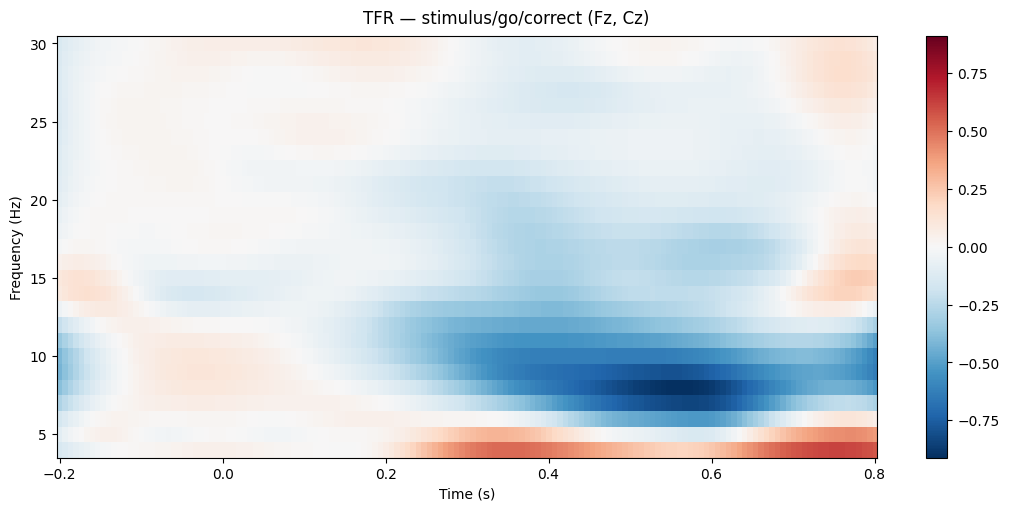

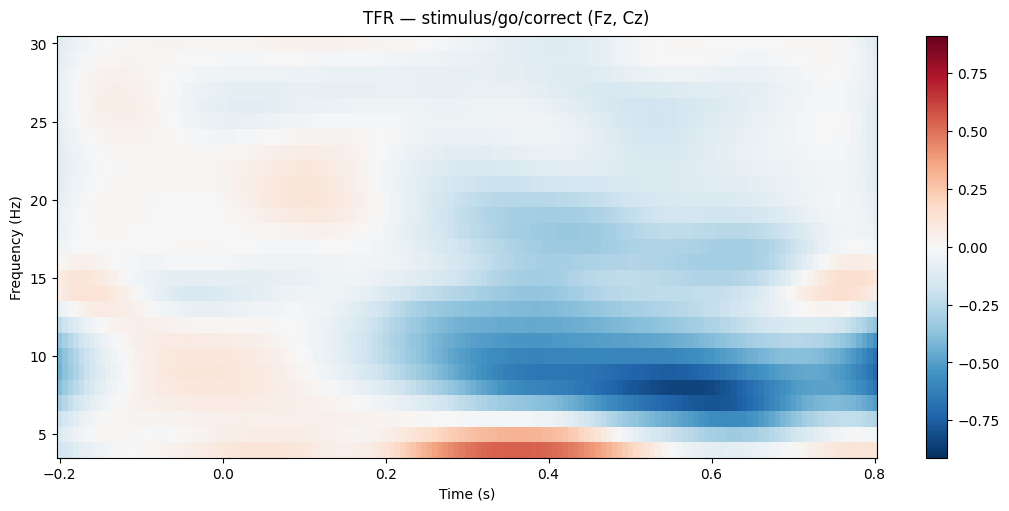

Calcul TFR pour stimulus/nogo/correct...
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
No baseline correction applied


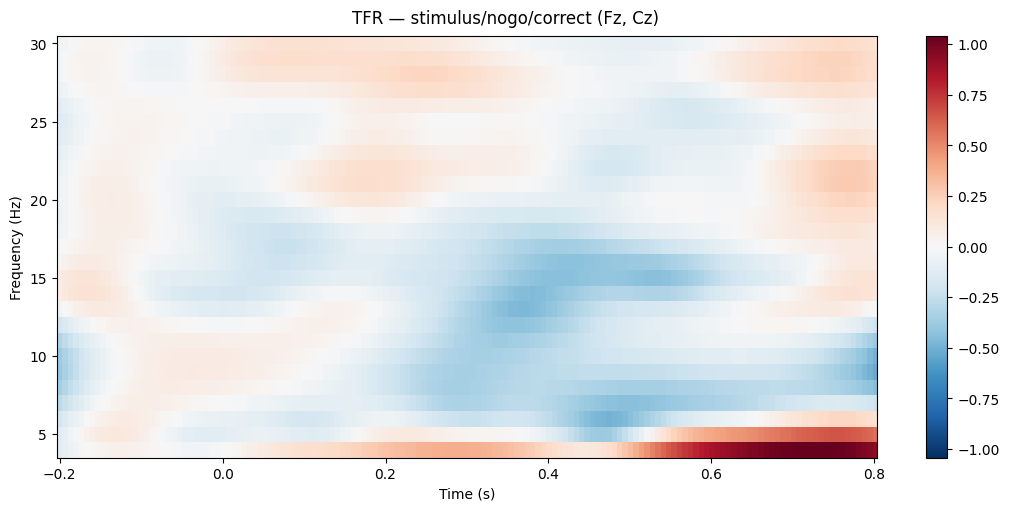

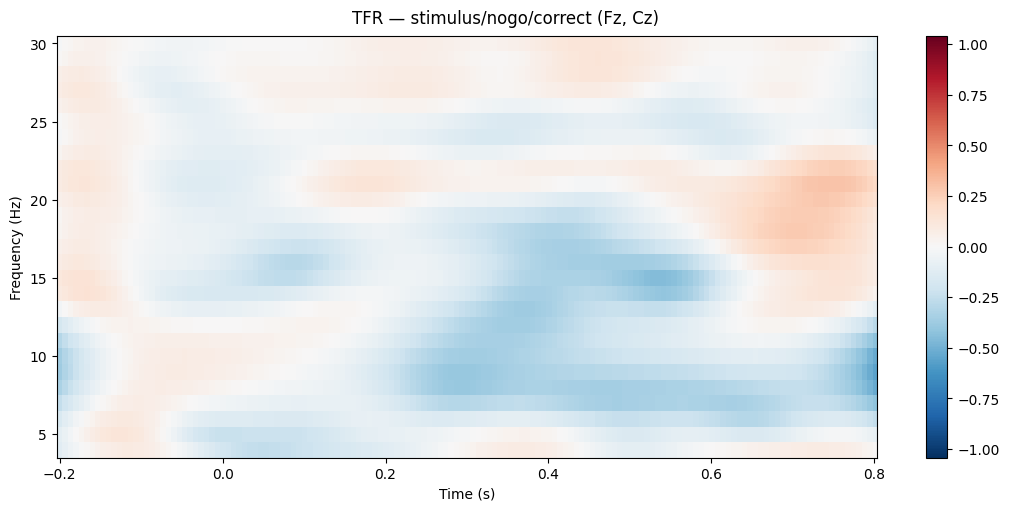

Affichage de la différence TFR (NoGo - Go)...
No baseline correction applied


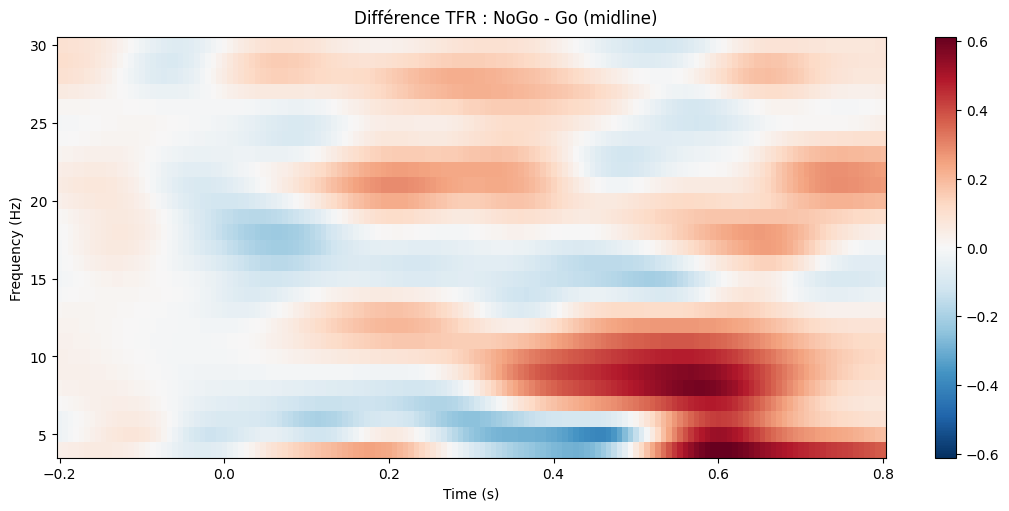

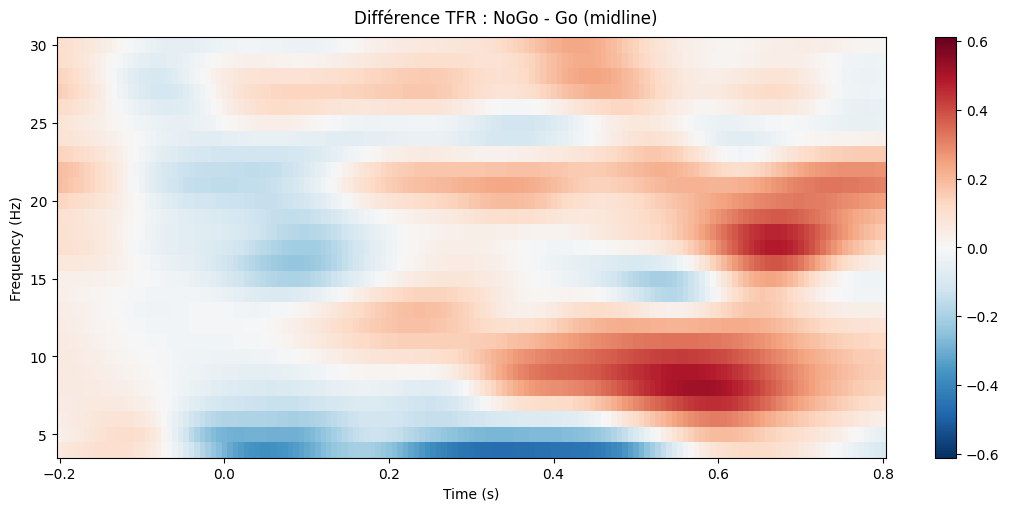

In [26]:
for label in plot_conditions:  # itère sur chaque condition à tracer (ici Go correct et NoGo correct)
    if label not in epochs.event_id or len(epochs[label]) == 0:  # vérifie que la condition existe et contient des epochs
        print(f'[skip] condition {label} manquante ou vide.')  # informe si la condition est absente ou vide
        continue  # passe à la condition suivante si non disponible

    print(f"Calcul TFR pour {label}...")  
    tfr_avg = tfr_morlet( 
        epochs[label].copy(),  # copie des epochs de la condition pour éviter de modifier l'objet original
        freqs=plot_freqs,  # vecteur des fréquences à analyser (ex: 4-30 Hz)
        n_cycles=plot_cycles,  # nombre de cycles pour chaque fréquence (contrôle résolution temps/fréq)
        picks=picks,  # sélection des canaux à utiliser (ex: Fz, Cz)
        average=True, # Calculer la moyenne des essais  # calcule la TFR moyenne sur les epochs (AverageTFR)
        return_itc=False,  # ne pas calculer la cohérence inter-trials (ITC)
        use_fft=True,  # utilise la FFT pour accélérer le calcul
        decim=TFR_DECIM,  # décimation temporelle pour réduire la résolution et accélérer
        n_jobs=-1, # Utiliser tous les coeurs  # parallélise sur tous les coeurs disponibles
        verbose=False,  # supprime les messages verbeux de tfr_morlet
    )
    tfr_avg.apply_baseline(TFR_BASELINE, mode=TFR_MODE, verbose=False)  # applique la normalisation baseline (p.ex. logratio)
    tfr_cache[label] = tfr_avg  # met en cache l'objet TFR calculé pour cette condition
    
    # Afficher le TFR (heatmap temps-fréquence)
    tfr_avg.plot(  # trace la TFR moyenne sous forme de heatmap
        picks=midline_picks,  # canaux à afficher dans le plot
        title=f"TFR — {label} ({', '.join(midline_picks)})",  # titre décrivant la condition et les canaux
        show=True,  # affiche la figure immédiatement
    )

# --- Plot de la Différence (NoGo - Go) ---
if set(plot_conditions).issubset(tfr_cache):  # vérifie que les deux conditions sont présentes dans le cache
    print("Affichage de la différence TFR (NoGo - Go)...")  # log avant d'afficher la différence
    diff_tfr = tfr_cache[plot_conditions[1]].copy() # NoGo  # copie la TFR NoGo comme base pour la différence
    diff_tfr.data -= tfr_cache[plot_conditions[0]].data # - Go  # soustrait la TFR Go pour obtenir la différence
    
    diff_tfr.plot(  # trace la TFR de différence
        picks=diff_tfr.ch_names,  # affiche tous les canaux présents dans l'objet diff_tfr
        title='Différence TFR : NoGo - Go (midline)',  # titre du graphique de différence
        show=True,  # affiche la figure
    )
else:
    print('Pas assez de conditions pour tracer la différence TFR.')  # message si la différence ne peut pas être calculée


### Bloc Type 3 — Visualiser les spectres pour d'autres cluster de région

Inspectons les densités de puissance pour les essais corrects de Go et NoGo sur les canaux de d'autre région en changeant la variable picks


### Bloc Type 2 — Visualiser les topographies de fréquence (optionnel)

C'est l'équivalent fréquentiel de `plot_topomap` pour les ERPs. Nous visualisons la distribution spatiale de la puissance pour des bandes et des fenêtres de temps spécifiques.


### Bloc Type 2 — Visualiser les spectres par condition

Avant d'extraire les features, inspectons quelques densités de puissance pour les essais corrects de Go et NoGo.
On applique les mêmes paramètres de baseline que ceux utilisés dans le pipeline d'extraction.


Affichage des topographies de la différence...
No baseline correction applied
No baseline correction applied
No baseline correction applied


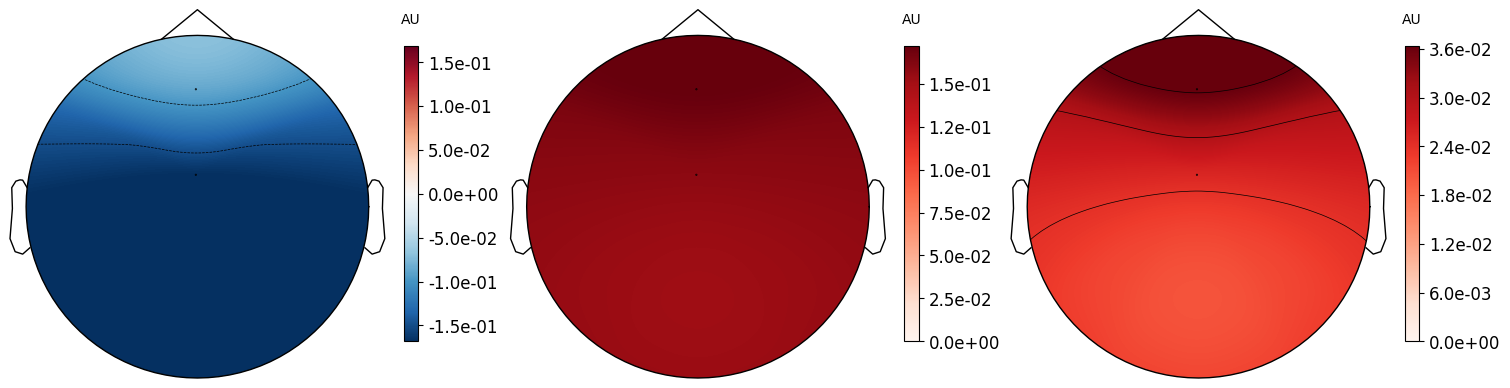

In [27]:
# Nous réutilisons le 'diff_tfr' (NoGo - Go) calculé ci-dessus
print("Affichage des topographies de la différence...")
    
# Définir les bandes d'intérêt
bands = {
    'Theta (4-7 Hz)': (4.0, 7.0),
    'Alpha (8-12 Hz)': (8.0, 12.0),
    'Beta (15-25 Hz)': (15.0, 25.0)
}

# Fenêtre de temps d'intérêt (post-stimulus)
tmin_topo, tmax_topo = 0.1, 0.5

fig, axes = plt.subplots(1, len(bands), figsize=(15, 5), constrained_layout=True)
if len(bands) == 1: axes = [axes] # Assurer que 'axes' est itérable

for ax, (band_name, (fmin, fmax)) in zip(axes, bands.items()):
    # Calculer la moyenne sur le temps et la fréquence
    diff_tfr.plot_topomap(
        fmin=fmin, fmax=fmax,
        tmin=tmin_topo, tmax=tmax_topo,
        axes=ax,
        show=False, 
        colorbar=True,
    )
plt.show()

### Bloc Type 3 — Explorer d'autres paramètres de bande

* Modifier `bands` pour ajouter d'autres bandes (gamma, delta) ou d'autres clusters.
* Ajuster `n_freqs`, `min_cycles` ou `decim` pour équilibrer résolution fréquentielle et bruit.
* Tester des configurations de `tmin/tmax` différentes pour cibler les effets post-stimulus.
* Utiliser `n_freqs` et `CHANNEL_CLUSTERS` pour ajouter les plots d'autres clusters.
* Utiliser `tfr_cache` pour ajouter les topomap de `go` où `nogo`.



## 4. Sauvegarder les features de bande par essai

Après avoir extrait la table `freq_features_df`, on peut la persister en CSV pour l'utiliser dans la suite.
Une copie est enregistrée dans `derivatives/gonogo-analysis`.


In [ ]:
output_csv = deriv_analysis / f'sub-{subject}_session-{session}_run-{run}_freqband_epochs.csv'
freq_features_df.to_csv(output_csv, index=False)
print('Table sauvegardée sous :', output_csv.resolve())
print('Colonnes enregistrées :', ', '.join(freq_features_df.columns.tolist()))


In [ ]:
print('Répartition des conditions :', freq_features_df['condition'].value_counts().to_dict())


### Bloc Type 2 — Vérifier la version sauvegardée

On peut relire rapidement le CSV généré pour vérifier la structure avant d'automatiser le pipeline multi-sujets.


In [ ]:
pd.read_csv(output_csv).head()


## 5. Extension multi-participants
## 5bis. Factoriser la collecte des features

Ce bloc reprend la logique d'extraction et la généralise à tous les participants BIDS pour produire des CSV consolidés.


In [ ]:
import pandas as pd
import numpy as np

def process_subject_features(subject: str, session: str, run: str, configs: dict, t_epoch: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    '''Exécute le pipeline complet pour un sujet donné.'''
    print(f"
--- Traitement Sujet : sub-{subject} ---")

    band_windows = configs['FREQUENCY_BAND_WINDOWS']

    raw = load_processed_raw(subject, session=session, run=run)

    print('  ... 1/5 Parsing des événements...')
    events, event_id = mne.events_from_annotations(raw)
    new_event_codes = {
        'stimulus/go/correct': 101,
        'stimulus/go/incorrect': 102,
        'stimulus/nogo/correct': 103,
        'stimulus/nogo/incorrect': 104,
    }

    go_onset_code = event_id.get(np.str_('go_onset'))
    nogo_onset_code = event_id.get(np.str_('nogo_onset'))
    go_correct_code = event_id.get(np.str_('go_correct'))
    nogo_correct_code = event_id.get(np.str_('nogo_correct'))
    incorrect_code = event_id.get(np.str_('incorrect'))

    stimulus_codes = [go_onset_code, nogo_onset_code]
    response_codes = [go_correct_code, nogo_correct_code, incorrect_code]

    new_events_list = []
    behavioral_data = []
    sfreq = raw.info['sfreq']
    trial_count = 0

    for i in range(len(events)):
        current_code = events[i, 2]
        if current_code not in stimulus_codes:
            continue
        trial_count += 1
        t_onset = events[i, 0]
        stim_type = 'go' if current_code == go_onset_code else 'nogo'
        found_response = False
        for j in range(i + 1, len(events)):
            next_code = events[j, 2]
            if next_code in response_codes:
                found_response = True
                t_response = events[j, 0]
                rt_sec = (t_response - t_onset) / sfreq
                if stim_type == 'go':
                    new_code = new_event_codes['stimulus/go/correct'] if next_code == go_correct_code else new_event_codes['stimulus/go/incorrect']
                    response = 'correct' if next_code == go_correct_code else 'incorrect'
                else:
                    if next_code == nogo_correct_code:
                        new_code = new_event_codes['stimulus/nogo/correct']
                        response = 'correct'
                        rt_sec = np.nan
                    else:
                        new_code = new_event_codes['stimulus/nogo/incorrect']
                        response = 'incorrect'
                break
            if next_code in stimulus_codes:
                found_response = False
                break
        if not found_response:
            rt_sec = np.nan
            if stim_type == 'go':
                new_code = new_event_codes['stimulus/go/incorrect']
                response = 'incorrect'
            else:
                new_code = new_event_codes['stimulus/nogo/correct']
                response = 'correct'

        new_events_list.append([t_onset, 0, new_code])
        behavioral_data.append({
            'subject': subject,
            'trial': trial_count,
            'stimulus': stim_type,
            'response': response,
            'rt_sec': rt_sec,
        })

    events_modified = np.array(new_events_list)
    selected_event_id = {
        label: code for label, code in new_event_codes.items() if code in events_modified[:, 2]
    }

    print('  ... 2/5 Création des époques...')
    epochs = mne.Epochs(
        raw,
        events_modified,
        event_id=selected_event_id,
        tmin=t_epoch['tmin'],
        tmax=t_epoch['tmax'],
        baseline=t_epoch['baseline'],
        picks='eeg',
        preload=True,
        detrend=None,
    )

    print('  ... 3/5 Extraction des puissances de bande...')
    df_features = build_frequency_feature_table(
        epochs,
        band_windows,
        subject_id=subject,
        session_id=session,
        run_id=run,
    )
    df_behavior = pd.DataFrame(behavioral_data)

    print(f"  ... 4/5 Sujet sub-{subject} terminé ({len(df_features)} essais).")
    return df_features, df_behavior

subjects_list = ['01', '02', '03', '04', '05', '06', '07', '08', '10', '12', '13', '14']
session = '001'
run = '01'

configs = {
    'FREQUENCY_BAND_WINDOWS': FREQUENCY_BAND_WINDOWS,
}

t_epoch = {
    'tmin': -0.2,
    'tmax': 0.8,
    'baseline': (-0.2, 0.0),
}

all_features = []
all_behaviors = []
print(f'Pipeline fréquence bandée pour {len(subjects_list)} sujets...')
for subject in subjects_list:
    df_feat, df_beh = process_subject_features(subject, session, run, configs, t_epoch)
    all_features.append(df_feat)
    all_behaviors.append(df_beh)

if all_features and all_behaviors:
    print('
--- Fusion des résultats multi-sujets ---')
    final_features_df = pd.concat(all_features, ignore_index=True)
    final_behavior_df = pd.concat(all_behaviors, ignore_index=True)
    output_features_csv = deriv_analysis / 'all_subjects_freqband_features.csv'
    output_behavior_csv = deriv_analysis / 'all_subjects_behavioral_data.csv'
    final_features_df.to_csv(output_features_csv, index=False)
    final_behavior_df.to_csv(output_behavior_csv, index=False)
    print('Features multi-sujets enregistrées :', output_features_csv.resolve())
    print('Data behaviour enregistrée :', output_behavior_csv.resolve())
    print('Dimensions features :', final_features_df.shape)
    print('Premières lignes :')
    print(final_features_df.head())
else:
    print('⚠️ Aucun sujet n'a pu être traité entièrement.')


## 6. Synthèse et prochaines étapes

1. L'exploration TFR illustre les différences Go vs NoGo dans les bandes theta/alpha sur la ligne médiane.
2. `freq_features_df` représente maintenant une matrice d'attributs par essai construite à partir des puissances de bande.
3. Chaque sujet exporte son propre CSV et le pipeline multi-participants consolide les features et les données comportementales.
4. Le prochain notebook pourra entraîner des modèles de classification sur ces features fréquentielles ou enrichir la table avec d'autres bandes (gamma, delta) ou des métriques temporelles additionnelles.
